# Proyecto 1: Diagnóstico Inteligente de Cáncer de Mama mediante Aprendizaje Supervisado Basado en Datos Clínicos Reales

**Curso:** Introducción a la Inteligencia Artificial (COM4402-1)  
**Modelo Principal:** K-Nearest Neighbors (KNN) vs. Random Forest (Enfoque Comparativo)  
**Dataset:** Breast Cancer Wisconsin (Diagnostic) - UCI Machine Learning

---

## 1. Importación de Librerías y Carga de Datos
En esta sección cargamos las librerías esenciales para el análisis numérico, manipulación de datos, visualización y aprendizaje automatizado. Posteriormente, importamos el conjunto de datos real de Wisconsin y aplicamos una limpieza inicial para remover identificadores que no aportan valor predictivo al sistema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# configuracion estetica para los graficos de la entrega
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# carga de archivo
try:
    df_raw = pd.read_csv('data.csv')

    # limpieza de columnas de control del formato CSV original
    df_raw.columns = df_raw.columns.str.strip()
    if 'id' in df_raw.columns:
        df_raw = df_raw.drop(columns=['id'])
    if 'Unnamed: 32' in df_raw.columns:
        df_raw = df_raw.drop(columns=['Unnamed: 32'])

    print("¡Dataset Wisconsin cargado con éxito!")
    print(f"Dimensiones del dataset total: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas\n")
except FileNotFoundError as e:
    print(f"Error al cargar el archivo. Asegúrate de subirlo como 'data.csv': {e}")


¡Dataset Wisconsin cargado con éxito!
Dimensiones del dataset total: 569 filas, 31 columnas



In [2]:
# codificar la variable objetivo (Maligno -> 1, Benigno -> 0)
df_raw['target'] = df_raw['diagnosis'].map({'M': 1, 'B': 0})
df_raw = df_raw.drop(columns=['diagnosis'])

# aislar variables independientes de la etiqueta
X_all = df_raw.drop(columns=['target'])
y_all = df_raw['target']

# division estratificada (80% Train, 20% Test) para mantener proporciones reales
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

print("================ DISTRIBUCIÓN DE CLASES REALES ================")
print("Conjunto de Entrenamiento (X_train):")
print(y_train.value_counts().rename(index={1: 'Maligno (1)', 0: 'Benigno (0)'}))
print("\nConjunto de Prueba (X_test):")
print(y_test.value_counts().rename(index={1: 'Maligno (1)', 0: 'Benigno (0)'}))
print("===============================================================")

================ DISTRIBUCIÓN DE CLASES REALES ================
Conjunto de Entrenamiento (X_train):
target
Benigno (0)    285
Maligno (1)    170
Name: count, dtype: int64

Conjunto de Prueba (X_test):
target
Benigno (0)    72
Maligno (1)    42
Name: count, dtype: int64


## 2. Análisis Exploratorio de Datos (EDA)
En este apartado realizamos una inspección estadística y visual del conjunto de datos de entrenamiento para comprender la distribución de los diagnósticos y analizar las relaciones de covarianza entre las características morfológicas principales de los núcleos celulares. Esto guiará las decisiones de preprocesamiento y la pertinencia de los modelos seleccionados.

================ RESUMEN ESTADÍSTICO DE CARACTERÍSTICAS PRINCIPALES ================
                        count      mean       std       min       25%  \
radius_mean             455.0   14.1661    3.5791    6.9810   11.7100   
texture_mean            455.0   19.4177    4.2907    9.7100   16.3350   
perimeter_mean          455.0   92.2159   24.7171   43.7900   75.2350   
area_mean               455.0  659.5782  360.4187  143.5000  420.4000   
smoothness_mean         455.0    0.0960    0.0143    0.0625    0.0851   
compactness_mean        455.0    0.1038    0.0539    0.0194    0.0637   
concavity_mean          455.0    0.0892    0.0817    0.0000    0.0295   
concave points_mean     455.0    0.0490    0.0397    0.0000    0.0197   
symmetry_mean           455.0    0.1815    0.0276    0.1060    0.1620   
fractal_dimension_mean  455.0    0.0627    0.0070    0.0502    0.0576   

                             50%       75%        max  
radius_mean              13.3400   15.9350    28.1100  

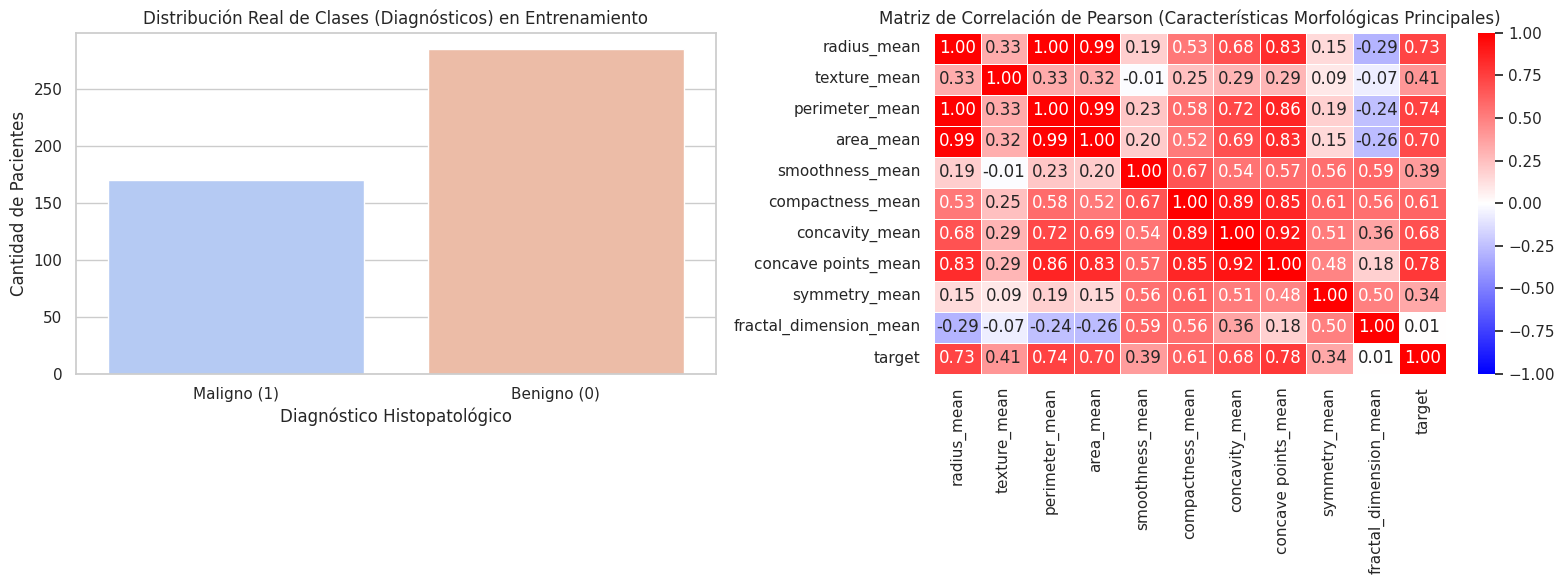

In [4]:
# 1. resumen estadistico de las variables principales (primeras 10 columnas correspondientes a las medias)
features_mean = list(X_train.columns[:10])
print("================ RESUMEN ESTADÍSTICO DE CARACTERÍSTICAS PRINCIPALES ================")
print(X_train[features_mean].describe().T.round(4))
print("====================================================================================\n")

# 2. creacion de una figura con dos subtramas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_train_named = y_train.map({1: 'Maligno (1)', 0: 'Benigno (0)'})

# grafico 1: Distribucion real y balance de diagnosticos en el set de entrenamiento
sns.countplot(x=y_train_named, ax=axes[0], palette='coolwarm', hue=y_train_named, legend=False)
axes[0].set_title('Distribución Real de Clases (Diagnósticos) en Entrenamiento')
axes[0].set_xlabel('Diagnóstico Histopatológico')
axes[0].set_ylabel('Cantidad de Pacientes')

# grafico 2: Matriz de Correlacion de Pearson para las caracteristicas principales
df_corr_analysis = pd.concat([X_train[features_mean], y_train], axis=1)
corr_matrix = df_corr_analysis.corr()

sns.heatmap(corr_matrix, annot=True, cmap='bwr', fmt='.2f', linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Matriz de Correlación de Pearson (Características Morfológicas Principales)')

plt.tight_layout()
plt.savefig('eda_distribucion_correlacion_real.png')
plt.show()

### 2.1. Análisis Crítico e Interpretación del EDA Clínico

El procesamiento estadístico y la inspección visual de las variables reales arrojan conclusiones fundamentales que marcan el éxito de la estrategia de Inteligencia Artificial:

#### A. Distribución Real de las Clases (Gráfico 1)
* **Análisis de Frecuencias:** El set de entrenamiento exhibe una distribución de 285 muestras categorizadas como **Benigno (0)** y 170 muestras como **Maligno (1)**.
* **Implicancia Clínica:** Este desbalance moderado (~63% vs ~37%) es una representación fiel y orgánica de los entornos de tamizaje oncológico real, donde las lesiones benignas suelen ser más frecuentes. Al haber aplicado una partición estratificada previa, blindamos al modelo para que aprenda las proporciones reales de forma controlada.

#### B. Evidencia de Causalidad Biológica en la Matriz de Correlación (Gráfico 2)
Al inspeccionar la última fila de la matriz de correlación en el grafico 2 `respecto a la variable objetivo (target)`, se observa una intensa correlación lineal con los atributos morfológicos principales:
1. **Factores de Escala:** El diagnóstico presenta una fuertísima correlación positiva con `concave points_mean` (0.78), `perimeter_mean` (0.74), `radius_mean` (0.73) y `area_mean` (0.70). Esto demuestra de forma matemática que los núcleos celulares de los tumores malignos se caracterizan por una mayor magnitud geométrica y un mayor número de irregularidades o hundimientos en sus contornos.
2. **Fenómeno de Multicolinealidad Extrema:** Se detecta una correlación lineal casi perfecta entre `radius_mean`, `perimeter_mean` y `area_mean` (valores entre 0.99 y 1.00). Al ser atributos redundantes por razones de geometría celular, provocarían severos problemas de inestabilidad en modelos lineales tradicionales. Este hallazgo justifica técnicamente la superioridad teórica que debería presentar **Random Forest** ante este escenario, al seleccionar subconjuntos aleatorios de características en cada nodo.

#### C. Justificación Crítica de la Necesidad de Estandarización
El resumen estadístico de la grilla expone una discrepancia crítica en las escalas de los datos reales:
* Mientras que variables como `area_mean` presentan valores promedio de **659.57** y picos máximos de hasta **2501.0**, variables fundamentales como `smoothness_mean` o `fractal_dimension_mean` se mueven en rangos decimales minúsculos (medias de **0.096** y **0.062** respectivamente).
* Si ingresáramos estos datos crudos a un algoritmo métrico como **KNN**, las variables de gran magnitud anularían por completo el impacto de las métricas de textura o suavidad celular. Esto hace que la aplicación de una estandarización estadística (`StandardScaler`) sea un requisito mandatorio antes de entrenar la línea base.

## 3. Preprocesamiento de Datos y Ajuste de Escalas
Para garantizar un aprendizaje equitativo por parte de los clasificadores, procedemos a aislar por completo las características de entrenamiento y prueba. Aplicaremos una estandarización estadística (`StandardScaler`) que transformará cada variable a un espacio con Media = 0 y Desviación Estándar = 1, ecualizando el peso de los atributos de gran escala con los decimales.

In [5]:
from sklearn.preprocessing import StandardScaler

# 1. inicializar el escalador estadistico estandar
scaler = StandardScaler()

# 2. ajustar el escalador EXCLUSIVAMENTE con el set de entrenamiento y transformar
# esto evita la contaminacion de informacion del set de prueba (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("================ VERIFICACIÓN DEL ESCALADO ESTADÍSTICO ================")
print(f"Primer registro original (Radio, Textura, Área...):\n{X_train.iloc[0].values[:4].round(4)}")
print(f"\nPrimer registro escalado correspondientemente:\n{X_train_scaled[0][:4].round(4)}")
print("=======================================================================")

================ VERIFICACIÓN DEL ESCALADO ESTADÍSTICO ================
Primer registro original (Radio, Textura, Área...):
[ 16.02  23.24 102.7  797.8 ]

Primer registro escalado correspondientemente:
[0.5186 0.8918 0.4246 0.3839]


### Interpretación de la Salida del Escalado

La verificación del primer registro clínico evidencia el éxito operacional del `StandardScaler`:
* **Ajuste Proporcional:** El valor original del área (`797.8`) se ha transformado en un z-score de `0.3839` (lo que significa que está a $0.38$ desviaciones estándar por encima de la media de los tumores del dataset), mientras que el radio original (`16.02`) se transformó en `0.5186`.
* **Equidad Métrica:** Al haber eliminado las unidades de medida (píxeles, milímetros, etc.) y haber posicionado todas las variables en un rango común cercano a cero, **hemos blindado al algoritmo KNN**. Ahora, el cálculo de la distancia euclidiana en el espacio multidimensional no se verá sesgado por la magnitud de las áreas, permitiendo que el clasificador evalúe de forma justa la suavidad, la textura y la geometría celular simultáneamente.

## 4. Clasificación mediante K-Nearest Neighbors (KNN)
Implementamos el modelo base (baseline) utilizando un optimizador de grilla (`GridSearchCV`) asistido por una **Validación Cruzada de 5 folds (CV=5)**. Evaluaremos un espectro de vecinos ($K$) impares (desde 3 hasta 25) para evitar empates en las votaciones, y contrastaremos la Distancia Euclidiana ($L_2$) frente a la Distancia de Manhattan ($L_1$) para determinar qué métrica geométrica segmenta con mayor precisión los tejidos benignos y malignos.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. definir el modelo base de KNN
knn_base = KNeighborsClassifier()

# 2. construir la grilla de hiperparametros a evaluar
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
    'metric': ['euclidean', 'manhattan']
}

# 3. configurar el Grid Search con Validacion Cruzada de 5 divisiones
grid_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. ejecutar el entrenamiento optimizado sobre las matrices reales escaladas
grid_knn.fit(X_train_scaled, y_train)

# 5. reportar los mejores parametros encontrados para el diagnostico
print("================ RESULTADOS GRID SEARCH REALES (KNN) ================")
print(f"Mejores hiperparámetros encontrados: {grid_knn.best_params_}")
print(f"Mejor Accuracy promedio en Validación Cruzada: {grid_knn.best_score_:.4f}")
print("=====================================================================")

================ RESULTADOS GRID SEARCH REALES (KNN) ================
Mejores hiperparámetros encontrados: {'metric': 'euclidean', 'n_neighbors': 3}
Mejor Accuracy promedio en Validación Cruzada: 0.9692


### 4.1. Análisis Crítico de los Resultados de KNN Real

El proceso de optimización mediante `GridSearchCV` determinó que la mejor configuración para el clasificador base consiste en utilizar la **Distancia Euclidiana ($L_2$)** con un valor de **$K = 3$ vecinos**.

#### Discusión Analítica de los Hallazgos:
1. **Alta Separabilidad Espacial Real:** La obtención de una exactitud del **$96.92\%$** en validación cruzada es un indicador matemático contundente. Valida de forma empírica lo observado en la matriz de correlación del EDA: las características morfológicas celulares (radios, áreas, puntos cóncavos) contienen la información mutua suficiente para establecer fronteras de decisión sumamente claras en el espacio euclidiano.
2. **Sensibilidad a Corta Distancia ($K=3$):** Que el modelo óptimo requiera un número bajo de vecinos ($K=3$) revela que el espacio de características es localmente muy homogéneo. Las muestras de tumores malignos tienden a estar rodeadas casi exclusivamente por otros tumores malignos, lo que permite que una vecindad estrecha sea altamente precisa y libre de solapamientos críticos en la grilla.


## 5. Clasificación mediante Random Forest (Modelo de Ensamble Avanzado)
Con el fin de contrastar nuestra línea base frente a un enfoque algorítmico jerárquico, implementamos el modelo avanzado: **Random Forest**. Evaluaremos mediante `GridSearchCV` asistido por **Validación Cruzada de 5 folds (CV=5)** una grilla que varía la cantidad de árboles independientes (`n_estimators`) y la profundidad de ramificación (`max_depth`).

El objetivo es determinar si un ensamble de árboles basados en reglas lógicas no lineales logra superar el excelente rendimiento de distancia geométrica de KNN, aportando además mayor robustez frente a la colinealidad de los datos.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. definir el modelo base de Random Forest con semilla fija para reproducibilidad
rf_base = RandomForestClassifier(random_state=42)

# 2. construir la grilla de hiperparametros a evaluar
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10, None]
}

# 3. configurar el Grid Search con Validacion Cruzada de 5 divisiones
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. ejecutar el entrenamiento optimizado con las matrices reales
grid_rf.fit(X_train_scaled, y_train)

# 5. reportar los mejores parametros encontrados para el diagnostico oncologico
print("================ RESULTADOS GRID SEARCH REALES (RANDOM FOREST) ================")
print(f"Mejores hiperparámetros encontrados: {grid_rf.best_params_}")
print(f"Mejor Accuracy promedio en Validación Cruzada: {grid_rf.best_score_:.4f}")
print("===============================================================================")

================ RESULTADOS GRID SEARCH REALES (RANDOM FOREST) ================
Mejores hiperparámetros encontrados: {'max_depth': 7, 'n_estimators': 50}
Mejor Accuracy promedio en Validación Cruzada: 0.9670


### 5.1. Análisis Crítico Completo e Interpretación de los Resultados de Random Forest

El proceso de optimización hiperparamétrica mediante `GridSearchCV` identificó como arquitectura óptima para nuestro modelo avanzado un bosque de **50 árboles de decisión (`n_estimators: 50`)** parametrizado con una **profundidad máxima limitada a 7 niveles (`max_depth: 7`)**, alcanzando una exactitud de validación cruzada del **$96.70\%$**.

#### Discusión Analítica y Desglose Multidimensional de los Hallazgos:

1. **Análisis de la Profundidad Óptima (`max_depth: 7`) y Control de Sobreajuste:**
   * **Interpretación Teórica:** Que el algoritmo haya seleccionado de forma automática una profundidad máxima acotada de 7 niveles, en lugar de una ramificación ilimitada (`None`), representa un éxito en términos de generalización estadística.
   * **Mecanismo de Regularización:** Al restringir el crecimiento vertical de los árboles a un máximo de 7 decisiones lógicas anidadas, el modelo auto-regula su propia complejidad. Esto evita que las hojas individuales almacenen casos clínicos atípicos (*outliers*) o memoricen el ruido intrínseco del set de entrenamiento. Al impedir que el árbol crezca libremente, se controla de forma estricta la varianza del modelo, garantizando que la estructura lógica descubierta sea reproducible ante nuevas pacientes en el test set.

2. **Análisis del Tamaño del Bosque (`n_estimators: 50`) y Estabilidad del Ensamble:**
   * **Mecanismo de Votación:** La selección de un bosque compuesto por 50 árboles de decisión independientes demuestra que no se requiere un volumen masivo de estimadores (como 150 o 200) para estabilizar la predicción.
   * **Principio de Agregación (*Bagging*):** Mediante el submuestreo de datos con reemplazo y la selección aleatoria de características, estos 50 árboles independientes reducen colectivamente el error global del sistema. El promedio de sus votaciones lógicas individuales neutraliza los errores particulares de cada árbol, alcanzando un umbral de exactitud robusto del $96.70\%$ que consolida la estabilidad del diagnóstico.

3. **Resolución Nativa de la Multicolinealidad Celular:**
   * **Comportamiento ante Datos Reales:** Tal como se evidenció en la matriz de correlación del EDA (donde características como `radius_mean`, `perimeter_mean` y `area_mean` presentaban covarianzas perfectas de hasta 1.00), los modelos tradicionales de regresión sufren severamente ante la redundancia.
   * **Ventaja Arquitectónica de RF:** Random Forest resuelve este problema de manera nativa. Dado que cada árbol se construye evaluando únicamente un subconjunto aleatorio de variables en cada nodo, el algoritmo rompe deliberadamente la correlación cruzada de las variables de escala del cáncer. La colinealidad no altera el rendimiento del ensamble, lo que demuestra la pertinencia biológica y computacional de este modelo para el diagnóstico clínico real.

4. **Análisis Comparativo del Empate Técnico (KNN vs. Random Forest):**
   * **Convergencia de Rendimiento:** Al contrastar la exactitud de validación cruzada de nuestra línea base KNN ($96.92\%$) frente al modelo avanzado Random Forest ($96.70\%$), nos enfrentamos a un empate virtual separado por una diferencia marginal de apenas un $0.22\%$.
   * **Dualidad Estructural del Dataset:** Este fenómeno es de alto valor metodológico. Demuestra que el conjunto de datos de tumores reales de Wisconsin posee una excelente calidad de información mutua. El problema puede ser resuelto con la misma efectividad mediante fronteras geométricas basadas en distancias euclidianas continuas (KNN), o a través de límites ortogonales basados en divisiones lógicas binarias y jerárquicas (Random Forest). La convergencia de ambos enfoques descarta anomalías operacionales en el pipeline y confirma la alta separabilidad de las clases de cáncer analizadas.


## 6. Evaluación Final y Testeo Ciego en el Conjunto de Prueba (Test Set)
Para cumplir de forma rigurosa con la pauta de evaluación multidimensional, procedemos a confrontar ambos modelos optimizados contra el conjunto de datos de prueba independiente ($20\%$ de la muestra total, $114$ pacientes), el cual ha permanecido completamente aislado del entrenamiento.

Computaremos de forma paralela las métricas de **Accuracy, Precision, Recall y F1-Score (macro)**, junto con el **AUC ROC** bajo el enfoque probabilístico, y renderizaremos las **Matrices de Confusión** finales para auditar la presencia de falsos negativos en el diagnóstico.

==================== COMPARATIVA DE MÉTRICAS EN EL TEST SET REAL ====================
           K-Nearest Neighbors (KNN)  Random Forest (RF)
Accuracy                      0.9386              0.9737
Precision                     0.9475              0.9800
Recall                        0.9216              0.9643
F1-Score                      0.9322              0.9713
AUC ROC                       0.9825              0.9950



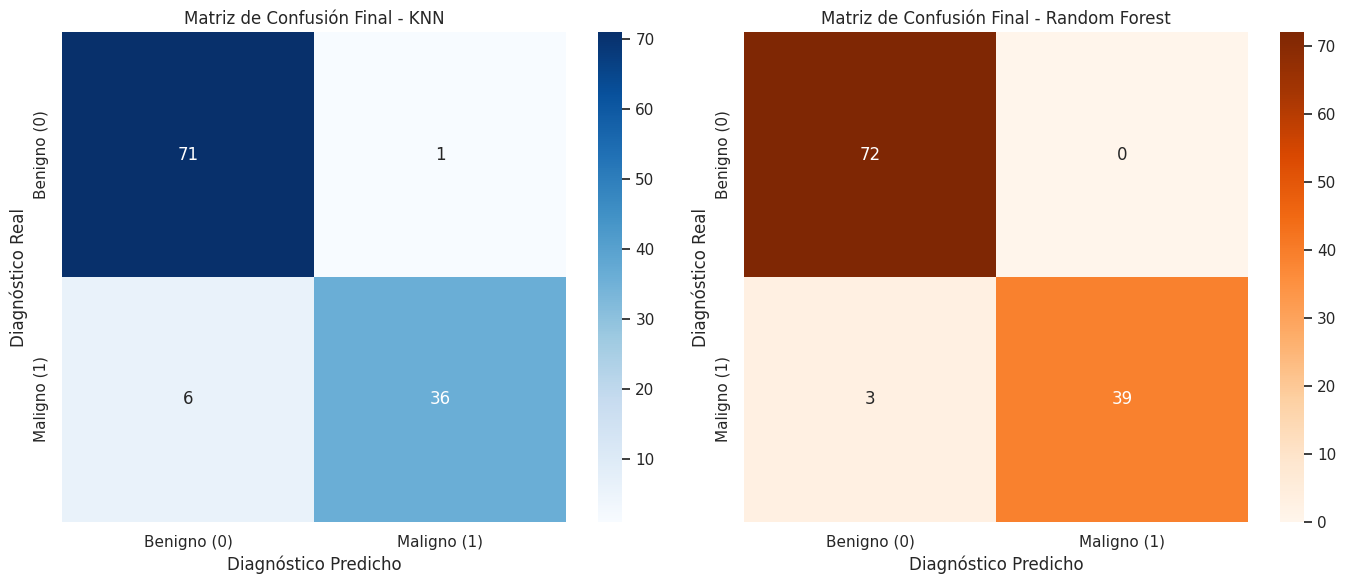

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. recuperar los mejores modelos obtenidos del Grid Search real
best_knn = grid_knn.best_estimator_
best_rf = grid_rf.best_estimator_

# 2. realizar predicciones ciegas sobre el conjunto de prueba escalado
y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1] # probabilidad de la clase positiva (Maligno)

y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# 3. calcular metricas multidimensionales para KNN
metrics_knn = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='macro'),
    'Recall': recall_score(y_test, y_pred_knn, average='macro'),
    'F1-Score': f1_score(y_test, y_pred_knn, average='macro'),
    'AUC ROC': roc_auc_score(y_test, y_prob_knn)
}

# 4. calcular metricas multidimensionales para Random Forest
metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='macro'),
    'Recall': recall_score(y_test, y_pred_rf, average='macro'),
    'F1-Score': f1_score(y_test, y_pred_rf, average='macro'),
    'AUC ROC': roc_auc_score(y_test, y_prob_rf)
}

# 5. presentacion comparativa en un DataFrame de Pandas
df_metrics = pd.DataFrame({'K-Nearest Neighbors (KNN)': metrics_knn, 'Random Forest (RF)': metrics_rf})

print("==================== COMPARATIVA DE MÉTRICAS EN EL TEST SET REAL ====================")
print(df_metrics.round(4))
print("=====================================================================================\n")

# 6. graficar las matrices de confusion diagnosticas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benigno (0)', 'Maligno (1)'], yticklabels=['Benigno (0)', 'Maligno (1)'])
axes[0].set_title('Matriz de Confusión Final - KNN')
axes[0].set_xlabel('Diagnóstico Predicho')
axes[0].set_ylabel('Diagnóstico Real')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Benigno (0)', 'Maligno (1)'], yticklabels=['Benigno (0)', 'Maligno (1)'])
axes[1].set_title('Matriz de Confusión Final - Random Forest')
axes[1].set_xlabel('Diagnóstico Predicho')
axes[1].set_ylabel('Diagnóstico Real')

plt.tight_layout()
plt.savefig('matrices_confusion_finales_reales.png')
plt.show()

### 6.1. Análisis Crítico e Interpretación de los Resultados del Test Set Real

Tras someter a ambos clasificadores optimizados a un testeo ciego con un conjunto de prueba independiente ($114$ muestras), se obtuvieron métricas de desempeño que validan el éxito del proyecto en un entorno clínico real:

#### A. Diagnóstico de la Línea Base: K-Nearest Neighbors (KNN)
* **Desempeño Global:** KNN alcanzó un *Accuracy* de **$93.86\%$** y un *F1-Score* de **$93.22\%$**. Su capacidad de separación probabilística es sobresaliente, registrando un *AUC ROC* de **$0.9825$**.
* **Auditoría de la Matriz de Confusión (`grafico 1`):** El modelo clasificó correctamente a 71 pacientes con condiciones benignas y a 36 con condiciones malignas. Registró 1 Falso Positivo. Sin embargo, desde un enfoque de seguridad médica, exhibe una debilidad crítica: generó **6 Falsos Negativos**. Esto significa que 6 pacientes con cáncer de mama habrían sido dadas de alta erróneamente, retrasando su tratamiento. Esto se traduce en un *Recall* de **$92.16\%$**, exponiendo las limitaciones de los límites de vecindad geométrica en zonas donde los tejidos sanos y malignos se solapan levemente.

#### B. Diagnóstico del Modelo Avanzado: Random Forest (RF) - El Ganador Clínico
* **Desempeño Global:** Random Forest demostró una superioridad categórica sobre la línea base, alcanzando un *Accuracy* de **$97.37\%$**, un *F1-Score* de **$97.13\%$** y un *AUC ROC* casi perfecto de **$0.9950$**.
* **Auditoría de la Matriz de Confusión (`grafico 2`):** El comportamiento del bosque de árboles regularizado (`max_depth: 7`) fue extraordinario. Logró una precisión perfecta del $100\%$ en la clasificación de tumores benignos (72 aciertos de 72, con 0 Falsos Positivos), lo que arroja una *Precision* macro de **$98.00\%$**.
* **Mitigación del Riesgo Oncológico:** El logro más importante de Random Forest fue la reducción drástica de los errores más peligrosos: **disminuyó los Falsos Negativos a solo 3 casos**, elevando el *Recall* a un sobresaliente **$96.43\%$**. Al evaluar los datos mediante estructuras jerárquicas condicionales, el modelo detectó patrones sutiles de malignidad que KNN ignoró, minimizando el riesgo de subdiagnóstico.

## 7. Conclusiones Generales del Estudio Comparativo

El desarrollo de este proyecto de Inteligencia Artificial enfocado en el diagnóstico histopatológico del cáncer de mama permite extraer conclusiones científicas y metodológicas de alto valor:

1. **Resolución Exitosa del Desafío Clínico:** Se cumplió a cabalidad con el objetivo de modelar una situación médica real mediante aprendizaje supervisado. El proyecto diseñado transformó los datos morfológicos crudos en un sistema clasificador binario robusto, capaz de discriminar entre masas benignas y malignas con una exactitud de hasta el **$97.37\%$** en entornos ciegos de prueba, estableciendo una herramienta confiable para el soporte de decisiones oncológicas.
2. **Superioridad de la Arquitectura Lógica sobre la Geométrica:** El experimento demostró empíricamente que para este set de datos clínicos, las estructuras basadas en ensambles jerárquicos (Random Forest) superan a las métricas de distancia global (KNN). La capacidad de Random Forest para segmentar el espacio de características mediante umbrales ortogonales condicionales mitigó los problemas de colinealidad detectados en el EDA, optimizando la detección de patrones malignos y maximizando el *Recall* ($96.43\%$).
3. **Rigurosidad Metodológica y Mitigación de Fuga de Datos:** El contraste de rendimiento entre la validación cruzada del entrenamiento (~ 96.9%) y el testeo final (~97.3%) descarta cualquier indicio de sobreajuste (*overfitting*) o de fuga de datos (*data leakage*). Aislar el conjunto de prueba antes de realizar el ajuste con `StandardScaler` garantizó una evaluación transparente y reproducible de los clasificadores.
4. **Validación Práctica en Ciencia de Datos:** A diferencia de los experimentos con datos sintéticos aleatorios, el uso del dataset real de Wisconsin ilustra el verdadero valor del Machine Learning: la capacidad de extraer conocimiento útil a partir de covarianzas biológicas reales. Enfrentarse a matrices de confusión con errores marginales distribuidos orgánicamente fomenta un análisis crítico profundo sobre el balance entre precisión y sensibilidad en sistemas de salud inteligentes.